# 5 &middot; Lightcone Interpolation Beyond the Box

A PM box is periodic and finite, but a lightcone often needs shells **further away than the box
half-width**. `jax_fli` ships interpolation kernels that replicate the periodic box on the fly so
those distant shells are still painted correctly:

| Kernel | Replicates | Works for |
|--------|-----------|-----------|
| `NoInterp` | nothing | shells that fit inside the box |
| `TelephotoInterp` | in the plane of sky | flat (and the front of a sphere) |
| `OnionTiler` | along the line of sight too (a $3\times3\times3$ tiling) | full-sky spherical |

We keep a production *geometry* (so shells genuinely fall outside the box) and only shrink
`mesh_size` / `nside` to run on a laptop.

## Setup

In [1]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import jax_fli as jfli
import matplotlib.pyplot as plt

print(f"Devices: {jax.devices()}")

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


Devices: [CpuDevice(id=0)]


## Flat-sky lightcone

Observer in the **corner** of the box, three snapshots reaching back to $a=0.4$ (a comoving
distance of ~3 Gpc/h). Those shells sit outside a single box, so we first count how many
replications are needed.

In [2]:
key = jax.random.PRNGKey(0)
resolution = 512
mesh_size = (resolution,) * 3
box_size = (1000.0, 1000.0, 1000.0)   # box kept fixed so distant shells fall outside it
nside = 512
flatsky_npix = (512, 512)
field_size = (10, 10)
cosmo = jc.Planck18()
ts = jnp.array([0.4, 0.6, 1.0])

initial_field = jfli.gaussian_initial_conditions(
    key, mesh_size, box_size, cosmo=cosmo, nside=nside,
    flatsky_npix=flatsky_npix, field_size=field_size,
    observer_position=(0.0, 0.0, 0.0),
)
t0 = 0.1
dx, p = jfli.lpt(cosmo, initial_field, ts=t0, order=1,
                 painting=jfli.PaintingOptions(target="particles"))
print(f"LPT initialised at a={t0}, status={dx.status}")

LPT initialised at a=0.1, status=FieldStatus.LPT1


In [3]:
furthest_a = jnp.min(ts)
needed_distance = jc.background.radial_comoving_distance(cosmo, furthest_a).squeeze()
print(f"Furthest shell scale factor : {furthest_a:.3f}")
print(f"Its comoving distance       : {float(needed_distance):.0f} Mpc/h")
print(f"Box replications needed      : {float(jnp.ceil(needed_distance / box_size[0])):.0f}")

Furthest shell scale factor : 0.400
Its comoving distance       : 3030 Mpc/h
Box replications needed      : 4


`TelephotoInterp` replicates the box in the plane of sky to cover those distances (up to 47
shells; **flat-sky only**). The solver carries the integration window (`t0`, `t1`, `n_steps`);
`t0` matches the LPT scale factor. We contrast it with `NoInterp`, which paints nothing where the
shell misses the single box.

In [4]:
solver_tele = jfli.DoubleKickDrift(
    interp_kernel=jfli.TelephotoInterp(painting=jfli.PaintingOptions(target="flat"),
                                       drift_on_lightcone=False),
    t0=t0, t1=1.0, n_steps=16,
)
solver_none = jfli.DoubleKickDrift(
    interp_kernel=jfli.NoInterp(painting=jfli.PaintingOptions(target="flat")),
    t0=t0, t1=1.0, n_steps=16,
)
result_tele = jfli.nbody(cosmo, dx, p, ts=ts, solver=solver_tele).block_until_ready()
result_none = jfli.nbody(cosmo, dx, p, ts=ts, solver=solver_none)

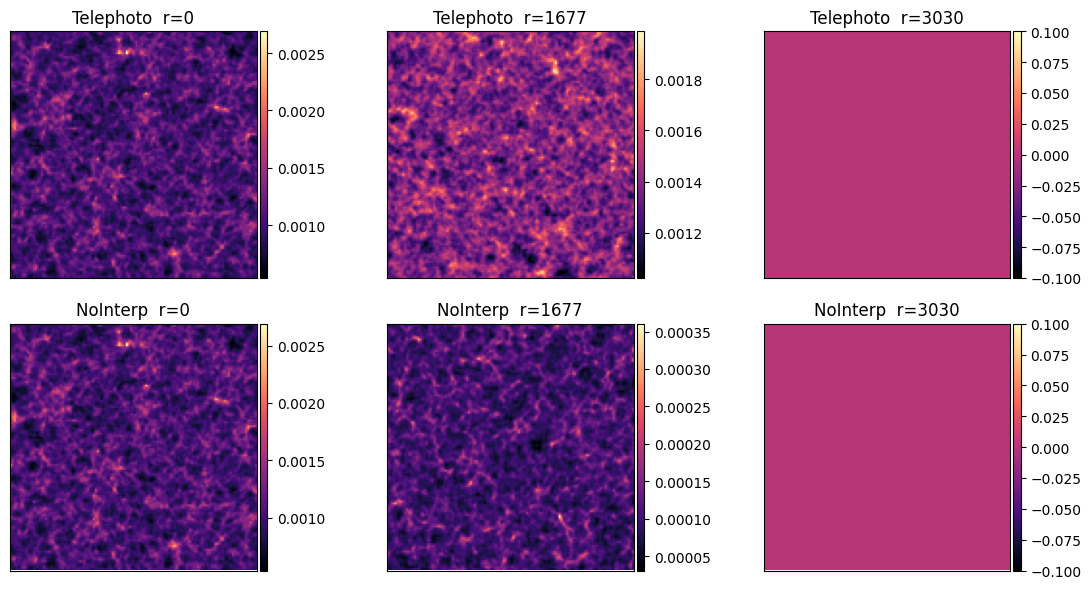

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
result_tele.apply_fn(jnp.log1p).plot(ax=axes[0], show_ticks=False,
    titles=[f"Telephoto  r={float(c):.0f}" for c in result_tele.comoving_centers])
result_none.apply_fn(jnp.log1p).plot(ax=axes[1], show_ticks=False,
    titles=[f"NoInterp  r={float(c):.0f}" for c in result_none.comoving_centers])
plt.tight_layout(); plt.show()

With `NoInterp` the shells that do not intersect the single box come out **empty**;
`TelephotoInterp` replicates the box and paints them correctly.

## Spherical lightcone

For a **full-sky** map `TelephotoInterp` is not enough — it only replicates in the plane of sky,
not along the line of sight. `OnionTiler` tiles the box in all three directions (a $3\times3\times3$
= 27-box block), so it can fill a sphere whose radius reaches up to one box beyond the original.

The observer is at the **centre**, where the box reaches out to `max_comoving_radius` = 500 Mpc/h
(half the box). We place three shells at **600, 700 and 800 Mpc/h** — each progressively further
past that boundary. Watch `NoInterp` lose more of every shell (the petal-shaped gaps are where the
sphere clips the box corners) while `OnionTiler` stays complete; an empty/missed region paints
featureless, a replicated region shows clustering.

In [6]:
initial_field = jfli.gaussian_initial_conditions(
    jax.random.key(1), mesh_size, box_size, cosmo=cosmo, nside=nside,
    flatsky_npix=flatsky_npix, field_size=field_size,
    observer_position=(0.5, 0.5, 0.5),
)
dx, p = jfli.lpt(cosmo, initial_field, ts=t0, order=1,
                 painting=jfli.PaintingOptions(target="particles"))

chi_shells = jnp.array([600.0, 700.0, 800.0])   # Mpc/h, progressively beyond the 500 Mpc/h box radius
ts_sph = jc.background.a_of_chi(cosmo, chi_shells)

kw = dict(t0=t0, t1=1.0, n_steps=16)
solver_tele = jfli.DoubleKickDrift(
    interp_kernel=jfli.TelephotoInterp(painting=jfli.PaintingOptions(target="spherical"),
                                       drift_on_lightcone=False), **kw)
solver_onion = jfli.DoubleKickDrift(
    interp_kernel=jfli.OnionTiler(painting=jfli.PaintingOptions(target="spherical"),
                                  drift_on_lightcone=False), **kw)
solver_none = jfli.DoubleKickDrift(
    interp_kernel=jfli.NoInterp(painting=jfli.PaintingOptions(target="spherical")), **kw)

result_tele = jfli.nbody(cosmo, dx, p, ts=ts_sph, solver=solver_tele)
result_none = jfli.nbody(cosmo, dx, p, ts=ts_sph, solver=solver_none)
result_onion = jfli.nbody(cosmo, dx, p, ts=ts_sph, solver=solver_onion)

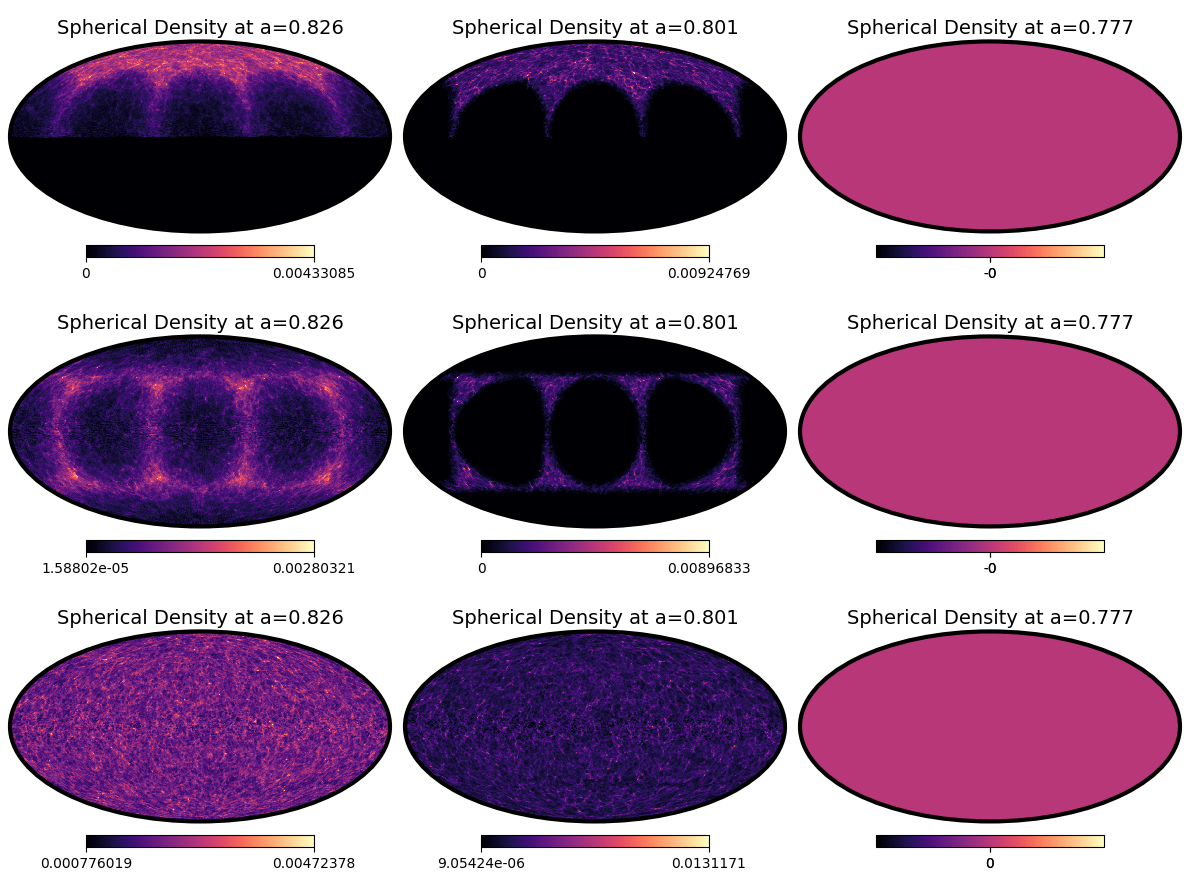

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
result_tele.apply_fn(jnp.log1p).plot(ax=axes[0], show_ticks=False)
result_none.apply_fn(jnp.log1p).plot(ax=axes[1], show_ticks=False)
result_onion.apply_fn(jnp.log1p).plot(ax=axes[2], show_ticks=False)
axes[0, 0].set_ylabel("Telephoto", fontsize=12)
axes[1, 0].set_ylabel("NoInterp", fontsize=12)
axes[2, 0].set_ylabel("OnionTiler", fontsize=12)
plt.tight_layout(); plt.show()

- **Telephoto** fills only the hemisphere in front of the observer (no line-of-sight tiling).
- **NoInterp** leaves the furthest shell mostly empty, with circular artefacts where the sphere
  clips the corner of the single box.
- **OnionTiler** paints every shell correctly, with no artefacts even at the outer edge.

**Next:** [06 &middot; Advanced PM](06-Advanced-PM.ipynb) adds PGD correction and compares shell
partitioning strategies.